In [3]:
#import the libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
import sqlite3 
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [4]:
#creating database connection 
conn = sqlite3.connect('Inventory.db')

df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.037271,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.042125,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.054746,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.061453,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.044932,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,1.893939,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,57.264957,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.351351,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,48.979592,97.469388


# EDA 
- Previously we examined the varios table in database to identify the variables ,understand the rltnship &  determine which ones should be include in the final analysis.
- In the pahse of EDA ,we will analyze the resultant table to gain insights into the distribution of each column. This will help us to understand data patterns ,identify anomlies ,and ensure data quality before proceeding with further analysis. 

In [7]:
# Summary Stastics 
df.describe().T


,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


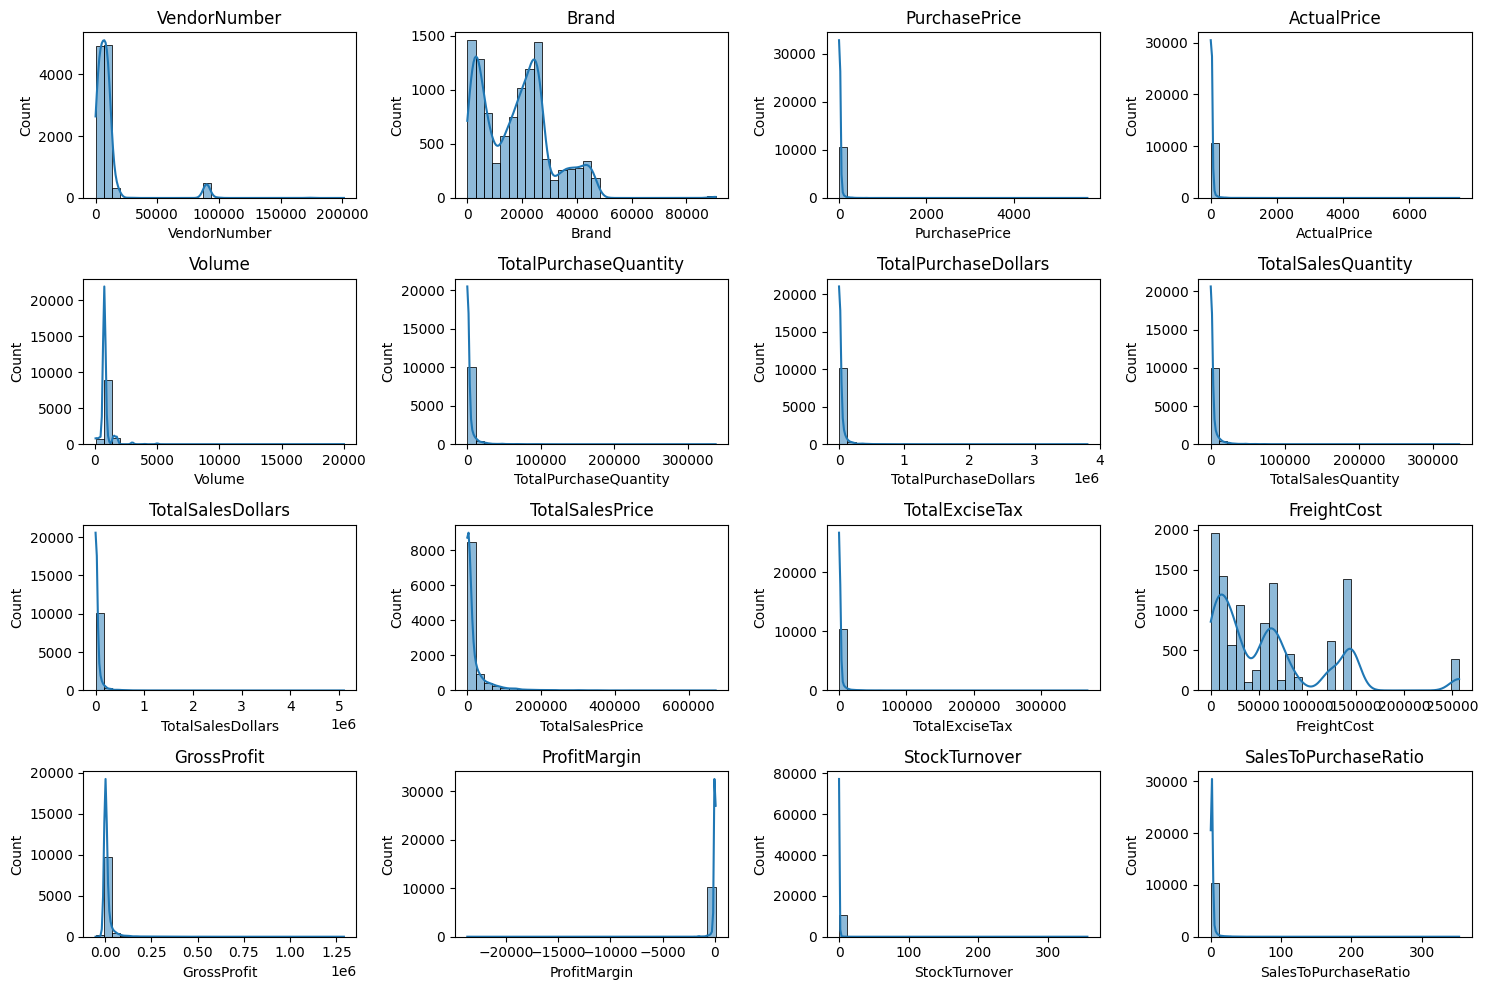

In [9]:
#Distribution plots for Numerical columns 

num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i , col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde = True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

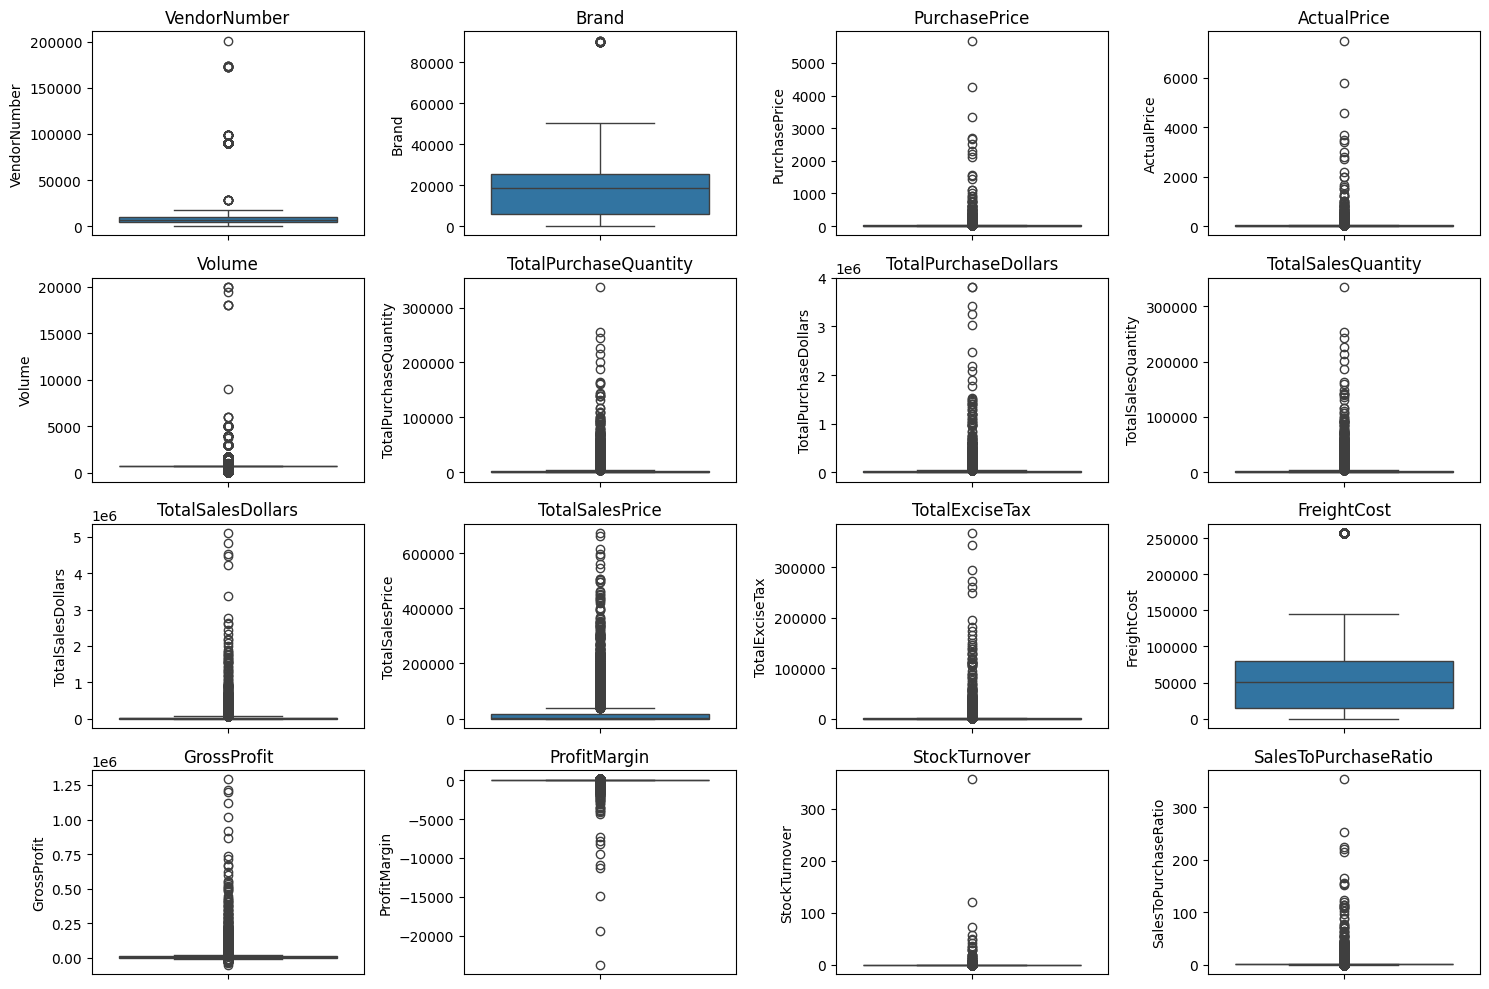

In [11]:
# Outlier Detection with Boxplots 
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i , col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()


## Summary Statistics Insights

**Negative & Zero Values:**

- **Gross Profit:** Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
- **Profit Margin:** Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.
- **Total Sales Quantity & Sales Dollars:** Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

**Outliers Indicated by High Standard Deviations:**

- **Purchase & Actual Prices:** The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- **Freight Cost:** Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- **Stock Turnover:** Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. A value more than 1 indicates that the sold quantity for that product is higher than the purchased quantity, due to sales being fulfilled from older stock.


In [12]:
#filter the data by removing inconsistence 

df = pd.read_sql_query("""SELECT *
from vendor_sales_summary
where GrossProfit > 0
And ProfitMargin >0
AND TotalSalesQuantity >0 """ ,conn)

In [13]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.037271,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.042125,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.054746,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.061453,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.044932,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,1.893939,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,57.264957,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.351351,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,48.979592,97.469388


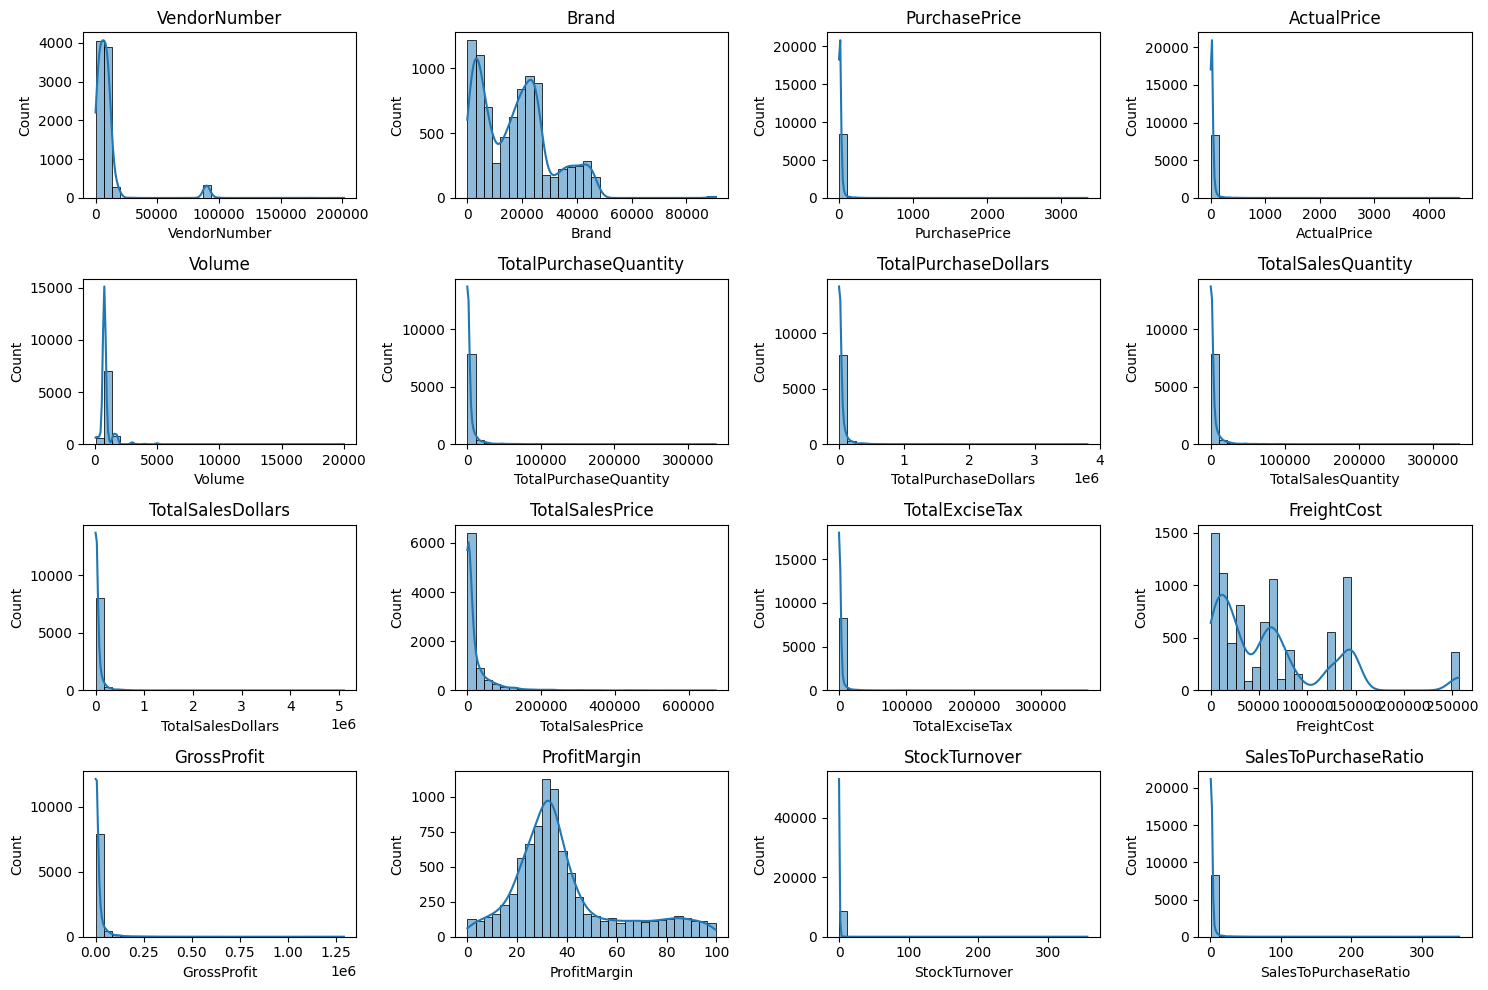

In [14]:
#Distribution plots for Numerical columns 

num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i , col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde = True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

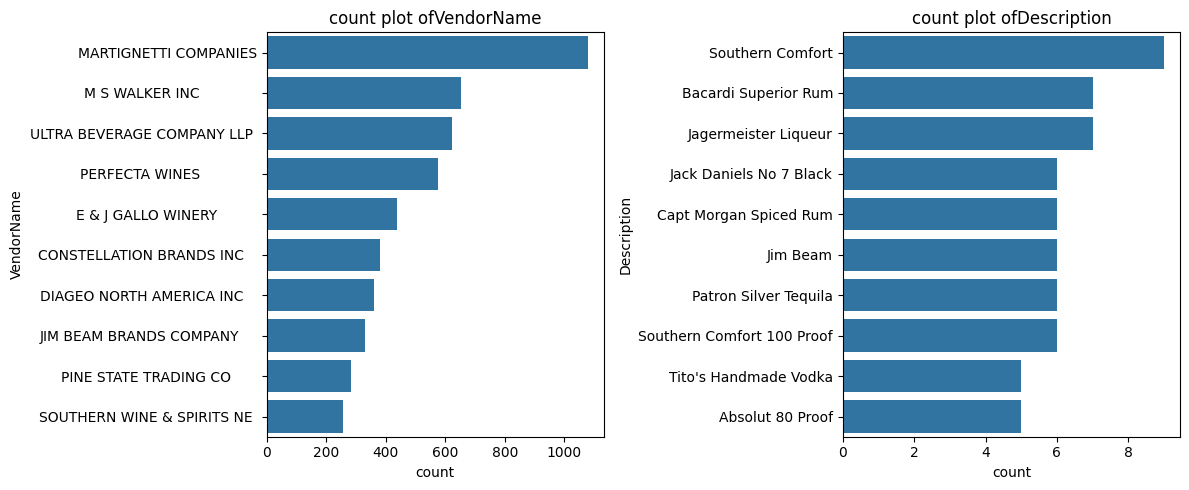

In [16]:
#count plots  for categorical columns

cat_cols = ["VendorName","Description"]

plt.figure(figsize=(12,5))
for i ,col in enumerate(cat_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"count plot of{col}")
plt.tight_layout()
plt.show()

    

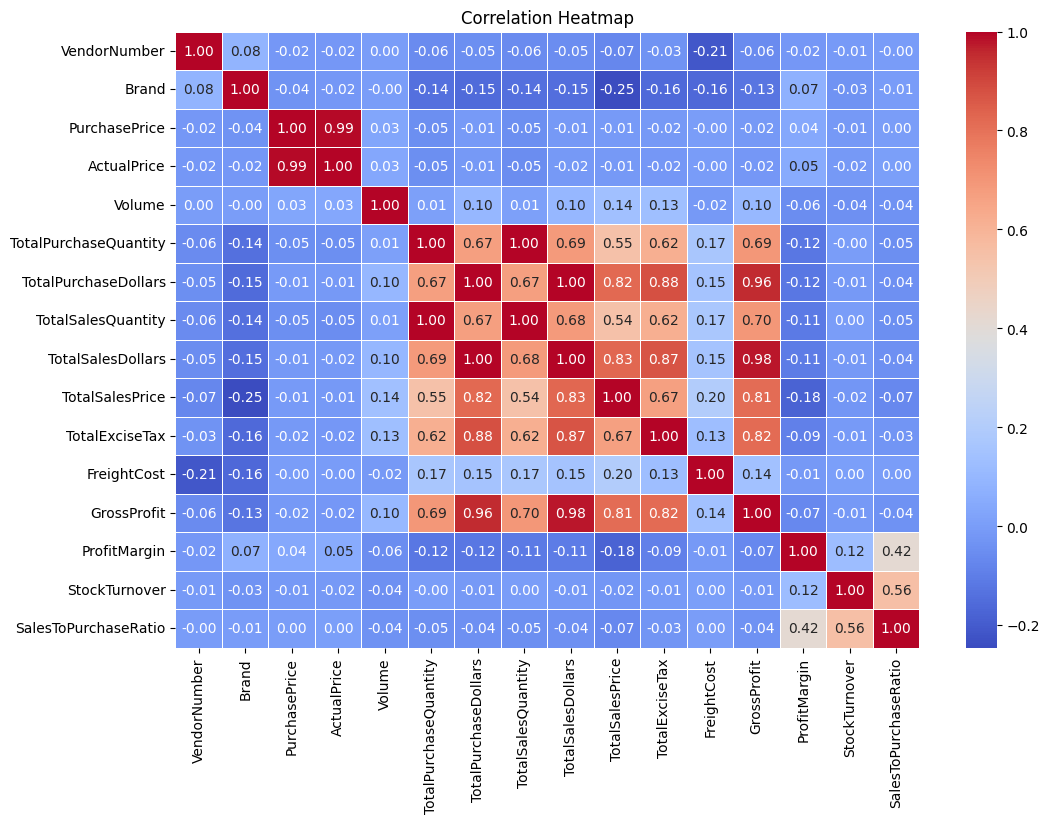

In [17]:
#correlation HeatMap
plt.figure(figsize=(12,8))
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap ="coolwarm",linewidth =0.5)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights

- **PurchasePrice** has weak correlations with **TotalSalesDollars** (-0.012) and **GrossProfit** (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.
- There is a strong correlation between **total purchase quantity** and **total sales quantity** (0.999), confirming efficient inventory turnover.
- There is a negative correlation between **profit margin** and **total sales price** (-0.179), which suggests that as the sales price increases, margins decrease, possibly due to competitive pricing pressures.
- **StockTurnover** has weak negative correlations with both **GrossProfit** (-0.038) and **ProfitMargin** (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

 ## Data Analysis
***Identify Brands that needs promotional or pricing adjustments with wxhibit lower sales perfomance but higher profit management.***

In [21]:
brand_perfomance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'})

In [24]:
low_sales_threshold = brand_perfomance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_perfomance['ProfitMargin'].quantile(0.85)


In [25]:
low_sales_threshold

np.float64(560.299)

In [27]:
high_margin_threshold

np.float64(64.97017552750113)

In [40]:
#filter Brands with low sales but high profit margins
target_brands = brand_perfomance[
    (brand_perfomance['TotalSalesDollars'] <= low_sales_threshold)&
    (brand_perfomance['ProfitMargin'] <= high_margin_threshold)
]

print("Brands with low sales but high profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

     


Brands with low sales but high profit Margins:


,TotalSalesDollars,ProfitMargin
Description,,
Terruzzi & Puthod Vernaccia,4.99,32.464930
Firefly Ridge Chard,5.79,31.088083
Albero Sparkling Wh Organic,5.79,28.497409
Smirnoff Light Strawberry,5.94,50.168350
Allen's Blue Curacao Liqueur,5.99,20.033389
...,...,...
Ch de Pez 10 St Estephe Brdx,558.87,45.046254
Pepperwood Grove Pnt Grigio,559.25,33.696916
La Fee NV Absinthe,559.72,44.847424


In [45]:
brand_perfomance = brand_perfomance[brand_perfomance["TotalSalesDollars"]<10000]

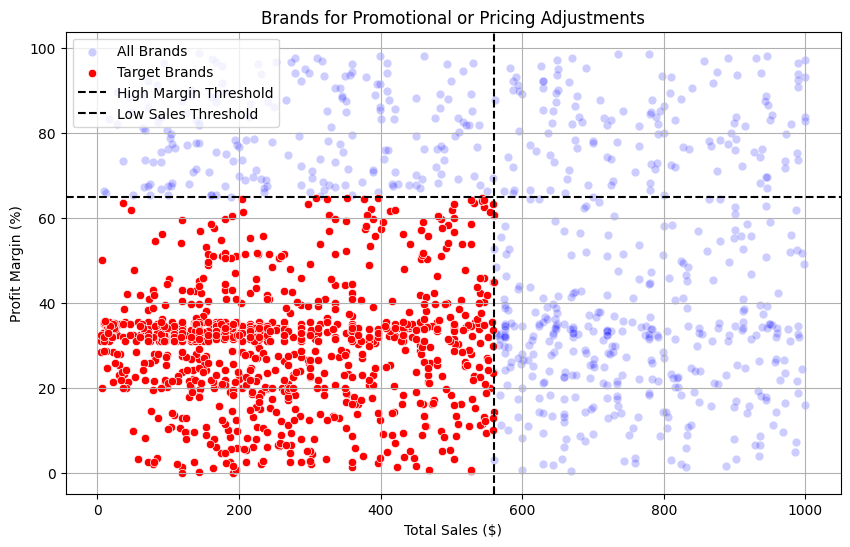

In [47]:
plt.figure(figsize=(10, 6))

# All brands (light blue, transparent)
sns.scatterplot(data=brand_perfomance, x='TotalSalesDollars', y='ProfitMargin',
                color="blue", label="All Brands", alpha=0.2)

# Target brands (red)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin',
                color="red", label="Target Brands")

# Threshold lines
plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

 ***Which Vendors and brands demonstrtae the highest sales perfomance?***

In [ ]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:2f}M"
    elif value >- 1_000:
        return f"{value / 1_000_000:2f}M"
    else:
        return str(value)

In [55]:
# Top vendors by sales perfomance 
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

In [58]:
top_vendors.apply(lambda x : format_dollars(x))

VendorName
DIAGEO NORTH AMERICA INC       67.990099M
MARTIGNETTI COMPANIES          39.276399M
PERNOD RICARD USA              32.063196M
JIM BEAM BRANDS COMPANY        31.423020M
BACARDI USA INC                24.854817M
CONSTELLATION BRANDS INC       24.218746M
E & J GALLO WINERY             18.399899M
BROWN-FORMAN CORP              18.247231M
ULTRA BEVERAGE COMPANY LLP     16.502544M
M S WALKER INC                 14.706459M
Name: TotalSalesDollars, dtype: str

In [60]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.964747M
Tito's Handmade Vodka      7.399658M
Grey Goose Vodka           7.209608M
Capt Morgan Spiced Rum     6.356321M
Absolut 80 Proof           6.244752M
Jameson Irish Whiskey      5.715760M
Ketel One Vodka            5.070084M
Baileys Irish Cream        4.150122M
Kahlua                     3.604859M
Tanqueray                  3.456698M
Name: TotalSalesDollars, dtype: str

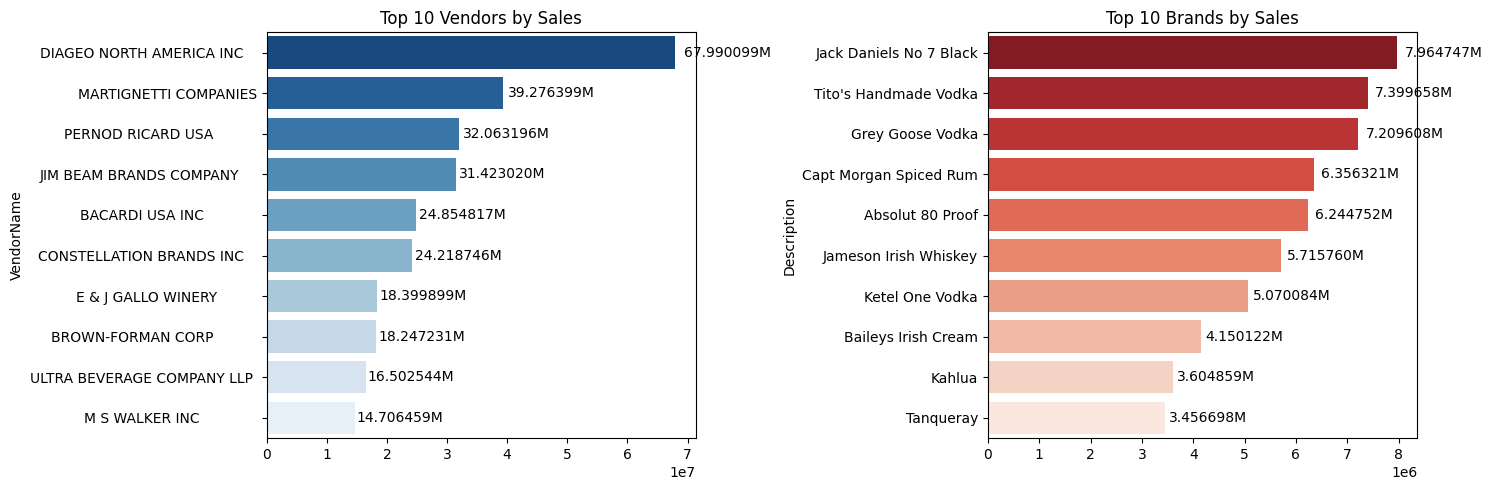

In [61]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

***Which Vendors contribute the Most  to Total Purchase Dollars?***


In [68]:
vendor_perfomance = df.groupby('VendorName').agg({
    "TotalPurchaseDollars" : "sum",
    "GrossProfit" : "sum",
    "TotalSalesDollars" : "sum",
}).reset_index()

In [69]:
vendor_perfomance["PurchaseContribution%"] = (
    vendor_perfomance["TotalPurchaseDollars"] / vendor_perfomance["TotalPurchaseDollars"].sum()
) * 100

In [70]:
vendor_perfomance = vendor_perfomance.sort_values("PurchaseContribution%", ascending=False)

In [71]:
vendor_perfomance["CumulativeContribution%"] = vendor_perfomance["PurchaseContribution%"].cumsum()

vendor_perfomance.head(10)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,CumulativeContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.300345,16.300345
57,MARTIGNETTI COMPANIES,25464774.04,13811624.76,39276398.80,8.285581,24.585926
69,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.760554,32.346479
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.644441,39.990920
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.671930,45.662850
20,CONSTELLATION BRANDS INC,15273708.08,8945037.57,24218745.65,4.969671,50.632520
11,BROWN-FORMAN CORP,13238939.18,5008291.47,18247230.65,4.307609,54.940130
30,E & J GALLO WINERY,12068539.22,6331360.24,18399899.46,3.926791,58.866921
107,ULTRA BEVERAGE COMPANY LLP,11167081.61,5335462.70,16502544.31,3.633480,62.500401
53,M S WALKER INC,9764312.60,4942145.91,14706458.51,3.177055,65.677457


In [73]:
top_vendors = vendor_perfomance.head(10)
top_vendors["TotalSalesDollars"]  = top_vendors["TotalSalesDollars"].apply(format_dollars)
top_vendors["TotalPurchaseDollars"]  = top_vendors["TotalPurchaseDollars"].apply(format_dollars)
top_vendors["GrossProfit"]  = top_vendors["GrossProfit"].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,CumulativeContribution%
25,DIAGEO NORTH AMERICA INC,50.097226M,17.892873M,67.990099M,16.300345,16.300345
57,MARTIGNETTI COMPANIES,25.464774M,13.811625M,39.276399M,8.285581,24.585926
69,PERNOD RICARD USA,23.851164M,8.212032M,32.063196M,7.760554,32.346479
46,JIM BEAM BRANDS COMPANY,23.494304M,7.928716M,31.423020M,7.644441,39.990920
6,BACARDI USA INC,17.432020M,7.422797M,24.854817M,5.671930,45.662850
20,CONSTELLATION BRANDS INC,15.273708M,8.945038M,24.218746M,4.969671,50.632520
11,BROWN-FORMAN CORP,13.238939M,5.008291M,18.247231M,4.307609,54.940130
30,E & J GALLO WINERY,12.068539M,6.331360M,18.399899M,3.926791,58.866921
107,ULTRA BEVERAGE COMPANY LLP,11.167082M,5.335463M,16.502544M,3.633480,62.500401
53,M S WALKER INC,9.764313M,4.942146M,14.706459M,3.177055,65.677457


In [75]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.67745684582755)

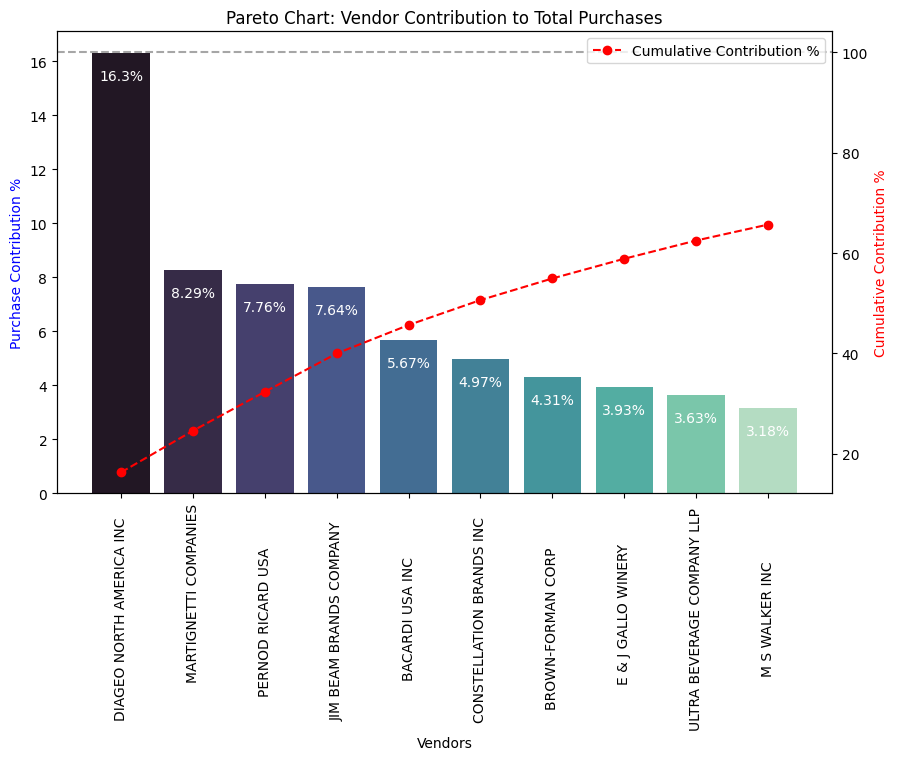

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 vendors (already sorted by contribution)
top_vendors = vendor_perfomance.head(10).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'],
            palette="mako", ax=ax1)

# Value labels on the bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(round(value, 2)) + '%',
             ha='center', fontsize=10, color='white')

# Line plot for Cumulative Contribution% (second y-axis)
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['CumulativeContribution%'],
         color='red', marker='o', linestyle='dashed', label='Cumulative Contribution %')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()


***How much of total procurement is dependant on the top vendors?***

In [78]:
print(f"Total Purchase contribution of top 10 vendor is{round(top_vendors["PurchaseContribution%"].sum(),2)}%")

Total Purchase contribution of top 10 vendor is65.68%


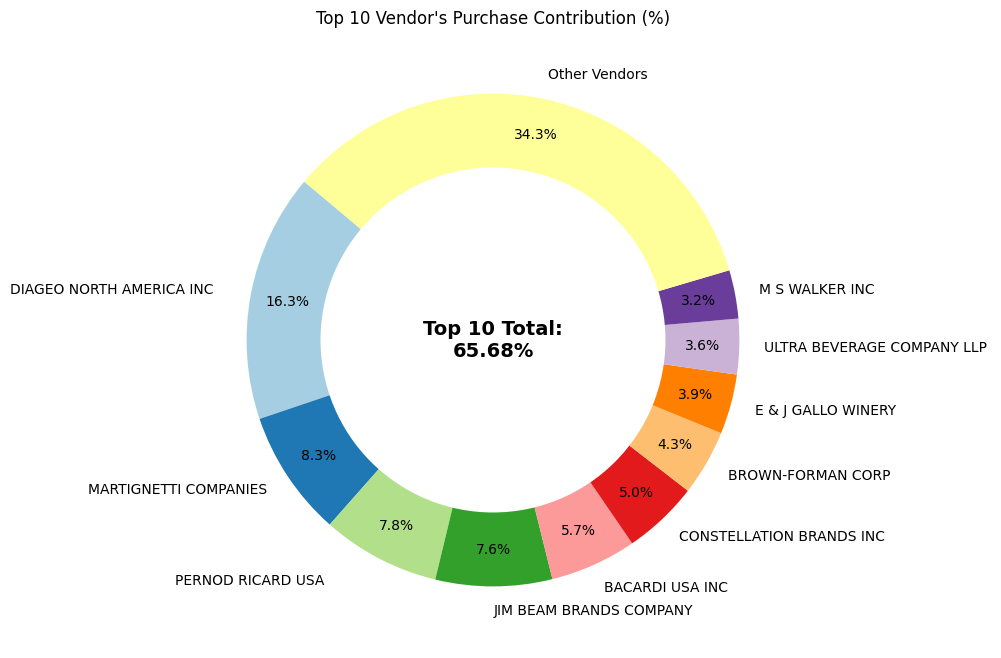

In [81]:
vendors = list(top_vendors["VendorName"].values)
purchase_contributions = list(top_vendors["PurchaseContribution%"].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%",
         fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

***Does Purchasing in bul reduce the unit price and what is the optimal purchase for cost savings?***

In [83]:
df["UnitPurchasePrice"] = df["TotalPurchaseDollars"] / df["TotalPurchaseQuantity"]


In [86]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"],q=3,labels =["Small","Medium","Large"])

In [89]:
df[["OrderSize","TotalPurchaseQuantity"]]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [90]:
df.groupby("OrderSize")[["UnitPurchasePrice"]].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


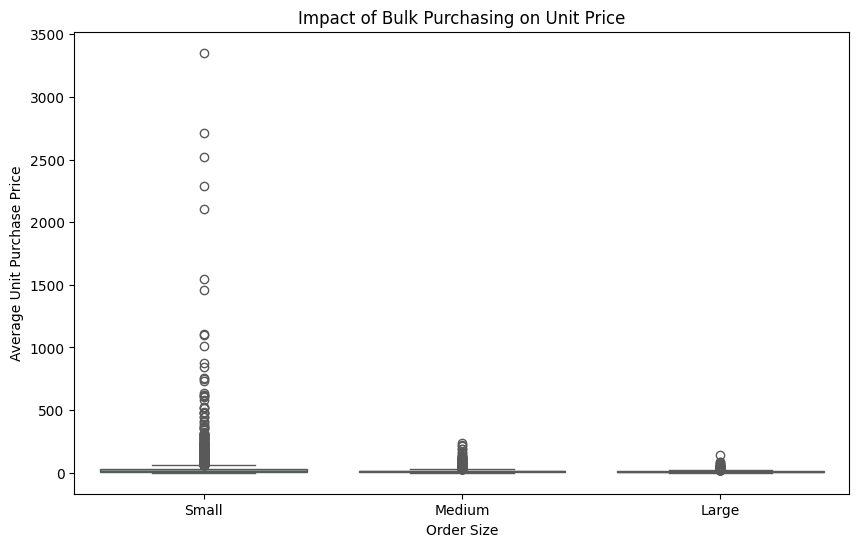

In [91]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

## Observations

- Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial (~72% reduction in unit cost).
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

***Which Vendors have low inventory turnover,indiacting excess stock and slow moving products?***

In [93]:
df[df["StockTurnover"] < 1].groupby("VendorName")["StockTurnover"].mean().sort_values()

VendorName
ALTAMAR BRANDS LLC             0.034938
CALEDONIA SPIRITS INC          0.036798
MARSALLE COMPANY               0.037491
TAMWORTH DISTILLING            0.041150
DJINN SPIRITS LLC              0.041987
                                 ...   
CAPSTONE INTERNATIONAL         0.237921
POVERTY LANE ORCHARDS          0.281983
STAR INDUSTRIES INC.           0.297006
FANTASY FINE WINES CORP        0.318719
SILVER MOUNTAIN CIDERS         0.634880
Name: StockTurnover, Length: 119, dtype: float64

***How much capital is locked in unsold inventory per vendor and which vendors contribute the most to do it?***

In [94]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.708177M


In [95]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,0.722209M
46,JIM BEAM BRANDS COMPANY,0.554666M
69,PERNOD RICARD USA,0.470626M
117,WILLIAM GRANT & SONS INC,0.401961M
30,E & J GALLO WINERY,0.228283M
80,SAZERAC CO INC,0.198436M
11,BROWN-FORMAN CORP,0.177734M
20,CONSTELLATION BRANDS INC,0.133618M
62,MOET HENNESSY USA INC,0.126478M
78,REMY COINTREAU USA INC,0.118598M


***What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.***

In [97]:
# Thresholds: top 25% and bottom 25% of sales
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Only the ProfitMargin column (a Series of numbers)
top_margins = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_margins = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

print(type(top_margins))   # should say pandas.Series

<class 'pandas.Series'>


In [99]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin = t_critical * std_err
    return mean_val, mean_val - margin, mean_val + margin



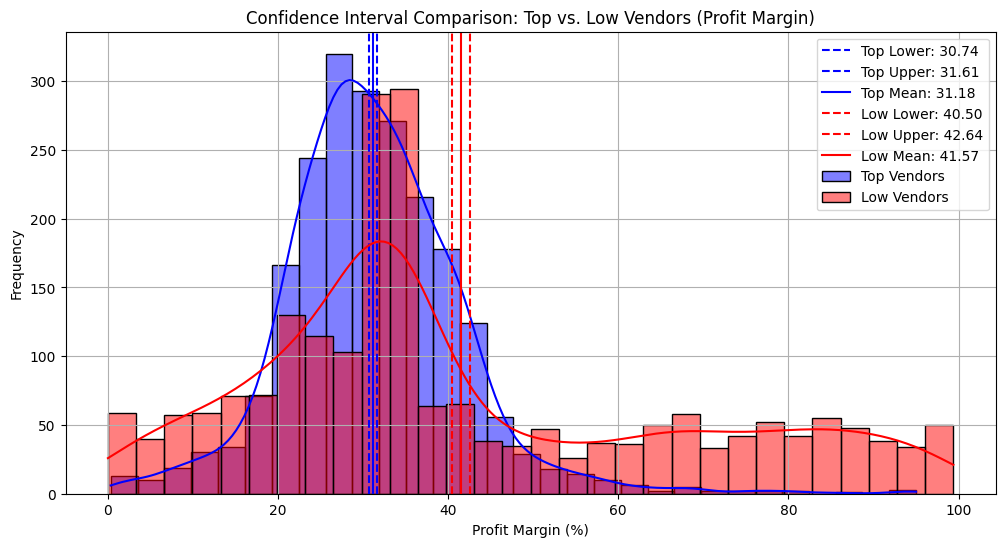

In [100]:
plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_margins, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_margins, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

## Observations

- The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- **For High-Performing Vendors:** If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- **For Low-Performing Vendors:** Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

## Is there a significant difference in profit margins between top-performing and low-performing vendors?

**Hypothesis:**

- **H₀ (Null Hypothesis):** There is no significant difference in the mean profit margins of top-performing and low-performing vendors.
- **H₁ (Alternative Hypothesis):** The mean profit margins of top-performing and low-performing vendors are significantly different.

In [102]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice,OrderSize,UnsoldInventoryValue
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,...,672819.31,260999.20,68601.68,1290667.91,25.297693,0.037271,1.338647,26.27,Large,79624.37
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,...,561512.37,294438.66,144929.24,1015032.27,21.062810,0.042125,1.266830,23.19,Large,87913.29
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,...,461140.15,343854.07,123780.22,1119816.92,24.675786,0.054746,1.327594,18.24,Large,4870.08
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,...,420050.01,368242.80,257032.07,1214774.94,27.139908,0.061453,1.372493,16.17,Large,20535.90
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,...,545778.28,249587.83,257032.07,1199901.61,28.412764,0.044932,1.396897,21.89,Large,49712.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,...,10.96,0.55,27100.41,13.31,83.448276,1.893939,6.041667,1.32,Small,-3.96
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,...,1.47,7.04,50293.62,63.32,96.436186,57.264957,28.059829,0.39,Small,-49.92
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,...,0.99,0.10,14069.87,0.50,25.252525,1.351351,1.337838,0.74,Small,0.00
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,...,77.61,15.12,257032.07,141.81,98.974037,48.979592,97.469388,1.47,Small,-104.37


In [104]:
# Save to CSV (index=False: row numbers ka extra column na bane)

vendor_sales_summary.to_csv('vendor_sales_summary.csv', index=False)

In [105]:
df.shape

(8564, 21)

In [106]:
df.columns


Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio',
       'UnitPurchasePrice', 'OrderSize', 'UnsoldInventoryValue'],
      dtype='str')

In [ ]:
BrandPerfomance = SUMMARIZE(vendors_sales_summary,vendors_sales_summary[Description],"TotalSales",SUM(vendors_sales_summary[TotalSalesDollars],"AvgProfitMargin",AVERAGE(vendors_sales_summary[ProfitMargin])))